<a href="https://colab.research.google.com/github/Hajer5503/Esprit-PI-4DS5-AgriSmart/blob/hajer-branch/modules/irrigation_rl/notebooks/Layer2_RL_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 AgriSmart — Layer 2 (PyTorch Double DQN + FAO-56 Simulator)

## What changed vs the sklearn version

| | sklearn MLP DQN | PyTorch Double DQN |
|---|---|---|
| Q-network | 5 separate MLPRegressors | One neural network, 5 output heads |
| Overestimation | High (same net selects + evaluates) | Fixed (Double DQN: online selects, target evaluates) |
| Target network | None | Separate frozen copy, soft-updated |
| GPU | No | Yes (if available) |
| Stability | Low | High |

## Training pipeline
1. **1000 synthetic seasons** (FAO-56 simulator calibrated from real ERA5 data)
2. **Phase 1**: Pre-train 300 episodes on synthetic seasons
3. **Phase 2**: Fine-tune 200 episodes on 3 real seasons (replay cleared)
4. **Evaluate**: Compare Pretrain+FT vs Real-only vs Rule-based on held-out test season

## 1. Install & Import

In [1]:
!pip install -q torch torchvision
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.10.0+cu128
Device : cuda


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, random, joblib, json, copy
from collections import deque

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports OK  |  Device: {DEVICE}")

✅ Imports OK  |  Device: cuda


## 2. Agronomic Constants

In [3]:
FC, WP   = 0.28, 0.12
TAW      = FC - WP
RAW      = 0.55 * TAW
SM_LOW   = WP + RAW    # 0.208 — stress threshold
SM_HIGH  = FC          # 0.28  — field capacity
ACTIONS  = [0, 5, 10, 15, 20]
N_ACTIONS = len(ACTIONS)

print(f"Optimal SM band : [{SM_LOW:.3f}, {SM_HIGH:.3f}]")
print(f"Actions         : {ACTIONS} mm/day")

Optimal SM band : [0.208, 0.280]
Actions         : [0, 5, 10, 15, 20] mm/day


## 3. FAO-56 Simulator (calibrated from real ERA5 data)

In [4]:
# ── Monthly climate stats extracted from 772 days of real ERA5 Tunisia data ──
MONTHLY_ET0_MEAN  = {11:2.574,12:1.834,1:2.090,2:2.375,3:3.915,4:4.570,5:5.294,6:6.216}
MONTHLY_ET0_STD   = {11:0.670,12:0.632,1:0.586,2:0.826,3:1.064,4:1.015,5:1.319,6:1.578}
MONTHLY_PRECIP_PROB={11:0.152,12:0.234,1:0.266,2:0.388,3:0.237,4:0.256,5:0.376,6:0.244}
MONTHLY_PRECIP_RATE={11:2.34, 12:4.24, 1:3.80, 2:2.97, 3:1.80, 4:3.04, 5:2.93, 6:2.45}
MONTHLY_TEMP_MEAN  = {11:17.57,12:13.76,1:12.61,2:13.22,3:16.68,4:18.43,5:22.17,6:25.73}
MONTHLY_TEMP_STD   = {11:2.91, 12:2.44, 1:2.48, 2:2.14, 3:2.67, 4:2.55, 5:2.54, 6:2.67}
MONTHLY_RH_MEAN    = {11:61.3, 12:68.7, 1:63.9, 2:68.1, 3:60.7, 4:58.6, 5:58.6, 6:56.6}

KC_X = [1, 15, 30,   50,   75,   100,  125,  150,  175,  200, 228]
KC_Y = [0.70,0.70,0.86,1.14,1.15,1.14,0.88,0.61,0.36,0.35,0.35]

def kc_at_day(d):
    return float(np.interp(d, KC_X, KC_Y))

def growth_stage_fn(d):
    if d<=20: return 0
    elif d<=50:  return 1
    elif d<=100: return 2
    elif d<=175: return 3
    else: return 4


def generate_synthetic_season(sid, rng, climate_factor=1.0):
    DAYS_PER_MONTH = {11:30,12:31,1:31,2:28,3:31,4:30,5:31,6:30}
    year_et0_mult  = rng.uniform(0.80, 1.20)
    year_rain_mult = rng.uniform(0.60, 1.60)
    rows = []
    m = 11
    day_in_m = 0

    for doy in range(1, 229):
        et0   = float(np.clip(rng.normal(MONTHLY_ET0_MEAN[m], MONTHLY_ET0_STD[m]) * year_et0_mult, 0.2, 12.0))
        rainy = rng.random() < (MONTHLY_PRECIP_PROB[m] * year_rain_mult * climate_factor)
        precip = float(min(rng.exponential(MONTHLY_PRECIP_RATE[m]) * climate_factor, 35.0)) if rainy else 0.0
        temp  = float(rng.normal(MONTHLY_TEMP_MEAN[m], MONTHLY_TEMP_STD[m]))
        rh    = float(np.clip(rng.normal(MONTHLY_RH_MEAN[m], 8.0), 20.0, 98.0))
        kc    = kc_at_day(doy)
        etc   = round(et0 * kc, 4)
        rows.append({'day_of_season':doy,'month':m,'et0_mm':round(et0,4),
                     'precip_mm':round(precip,4),'temp_c':round(temp,4),
                     'rh_pct':round(rh,2),'kc':round(kc,4),'etc_mm':etc,
                     'growth_stage':growth_stage_fn(doy)})
        day_in_m += 1
        if day_in_m >= DAYS_PER_MONTH.get(m,30):
            day_in_m = 0
            m = (m % 12) + 1
            if m == 7: m = 11

    df = pd.DataFrame(rows)

    # Soil moisture: mean-reverting model (calibrated from real data)
    SM_MEAN, ALPHA, BETA, NOISE = 0.215, 0.06, 0.000381, 0.003
    sm = float(rng.uniform(0.185, 0.240))
    sms, sm_sh, sm_dp = [], [], []
    for _, row in df.iterrows():
        sms.append(round(sm, 6))
        sm_sh.append(round(float(np.clip(sm * rng.uniform(0.85,0.95), WP, FC)), 6))
        sm_dp.append(round(float(np.clip(sm * rng.uniform(1.02,1.08), WP, FC+0.02)), 6))
        net = row['precip_mm'] - row['etc_mm']
        sm  = float(np.clip(sm + ALPHA*(SM_MEAN-sm) + BETA*net + rng.normal(0,NOISE), WP, FC+0.02))

    df['sm_root']      = sms
    df['sm_shallow']   = sm_sh
    df['sm_deep']      = sm_dp
    df['irrigation_mm'] = 0.0
    df['season_id']    = sid
    return df


# Test
rng_t = np.random.default_rng(0)
ts = generate_synthetic_season(0, rng_t)
print(f"Season shape : {ts.shape}")
print(f"SM mean={ts['sm_root'].mean():.4f}  "
      f"stressed={( ts['sm_root']<SM_LOW).mean()*100:.1f}%  "
      f"optimal={((ts['sm_root']>=SM_LOW)&(ts['sm_root']<=SM_HIGH)).mean()*100:.1f}%")

Season shape : (228, 14)
SM mean=0.2050  stressed=58.8%  optimal=41.2%


## 4. Generate 1000 Synthetic Seasons

In [5]:
N_SYNTHETIC = 1000
rng_main = np.random.default_rng(seed=42)
synthetic_seasons, climate_types = [], {'dry':0,'normal':0,'wet':0}

for i in range(N_SYNTHETIC):
    r = rng_main.random()
    if r < 0.25:   cf = rng_main.uniform(0.70,0.85); climate_types['dry']    += 1
    elif r < 0.75: cf = rng_main.uniform(0.90,1.10); climate_types['normal'] += 1
    else:          cf = rng_main.uniform(1.15,1.40); climate_types['wet']    += 1
    synthetic_seasons.append(generate_synthetic_season(i, rng_main, cf))

all_sm   = pd.concat([s['sm_root'] for s in synthetic_seasons])
all_et0  = pd.concat([s['et0_mm']  for s in synthetic_seasons])
print(f"Generated {N_SYNTHETIC} synthetic seasons  |  {climate_types}")
print(f"SM  mean={all_sm.mean():.4f}  stressed={( all_sm<SM_LOW).mean()*100:.1f}%  "
      f"optimal={((all_sm>=SM_LOW)&(all_sm<=SM_HIGH)).mean()*100:.1f}%")
print(f"ET0 mean={all_et0.mean():.3f} ± {all_et0.std():.3f} mm/day")

Generated 1000 synthetic seasons  |  {'dry': 247, 'normal': 490, 'wet': 263}
SM  mean=0.2072  stressed=54.0%  optimal=46.0%
ET0 mean=3.473 ± 1.792 mm/day


## 5. Load Layer 1 & Add Predictions

In [6]:
l1_sm  = joblib.load('layer1_model_sm_root.pkl')
l1_et0 = joblib.load('layer1_model_et0.pkl')
with open('layer1_feature_cols.json')     as f: L1_FEATURES  = json.load(f)
with open('layer1_et0_feature_cols.json') as f: ET0_FEATURES = json.load(f)
print(f"L1 sm_root: {type(l1_sm).__name__} ({len(L1_FEATURES)} features)")
print(f"L1 ET₀    : {type(l1_et0).__name__} ({len(ET0_FEATURES)} features)")


def add_l1_predictions(df):
    d = df.copy()
    lag_cols = ['sm_root','et0_mm','etc_mm','precip_mm','kc']
    for c in lag_cols:
        if c in d.columns:
            for lag in [1,3,7]: d[f'{c}_lag{lag}'] = d[c].shift(lag)
    for c,fs in [('sm_root',['mean','std']),('et0_mm',['mean','sum']),('precip_mm',['sum'])]:
        if c in d.columns:
            for f in fs: d[f'{c}_roll7_{f}'] = d[c].rolling(7,min_periods=1).agg(f)

    doy = d['day_of_season'] + 319
    d['sin_doy'] = np.sin(2*np.pi*doy/365); d['cos_doy'] = np.cos(2*np.pi*doy/365)
    LAT=np.radians(36.0)
    dr=1+0.033*np.cos(2*np.pi*doy/365); decl=0.409*np.sin(2*np.pi*doy/365-1.39)
    ws=np.arccos(np.clip(-np.tan(LAT)*np.tan(decl),-1,1))
    d['Ra']=((24*60/np.pi)*0.0820*dr*(ws*np.sin(LAT)*np.sin(decl)+np.cos(LAT)*np.cos(decl)*np.sin(ws)))
    d['et0_hargreaves']=(0.0023*(d['temp_c']+17.8)*np.sqrt(np.clip(d['temp_c']*0.4,0.1,30))*d['Ra']*0.408)
    d['shortwave_radiation']=d['Ra']*11.57; d['Rs_MJ']=d['shortwave_radiation']*0.0864; d['Rns']=(1-0.23)*d['Rs_MJ']
    d['vpd']=(1-d['rh_pct']/100)*0.6108*np.exp(17.27*d['temp_c']/(d['temp_c']+237.3))
    for lag in [1,3,7,10,14]:
        d[f'shortwave_radiation_lag{lag}']=d['shortwave_radiation'].shift(lag)
        d[f'Rs_MJ_lag{lag}']=d['Rs_MJ'].shift(lag)
    for lag in [1,3,7]:
        d[f'Ra_lag{lag}']=d['Ra'].shift(lag); d[f'et0_hargreaves_lag{lag}']=d['et0_hargreaves'].shift(lag)
        d[f'vpd_lag{lag}']=d['vpd'].shift(lag)
    for lag in [10,14]:
        d[f'vpd_lag{lag}']=d['vpd'].shift(lag); d[f'et0_mm_lag{lag}']=d['et0_mm'].shift(lag)

    for c in ['sm_shallow','sm_deep','irrigation_mm','wind_kmh']:
        if c not in d.columns: d[c] = {'sm_shallow':d['sm_root']*0.90,'sm_deep':d['sm_root']*1.05,
                                        'irrigation_mm':0.0,'wind_kmh':8.5}[c]
    for c in ['sm_shallow','sm_deep','irrigation_mm','temp_c','precip_mm','etc_mm','sm_root']:
        for lag in [1,3,7]:
            if f'{c}_lag{lag}' not in d.columns: d[f'{c}_lag{lag}']=d[c].shift(lag)
    for c,fs in [('sm_root',['mean','std']),('et0_mm',['mean','sum']),
                  ('temp_c',['mean']),('irrigation_mm',['sum'])]:
        for f in fs:
            if f'{c}_roll7_{f}' not in d.columns: d[f'{c}_roll7_{f}']=d[c].rolling(7,min_periods=1).agg(f)

    d = d.dropna(subset=['sm_root_lag7']).reset_index(drop=True)
    miss_l1  = [f for f in L1_FEATURES  if f not in d.columns]
    miss_et0 = [f for f in ET0_FEATURES if f not in d.columns]
    if miss_l1 or miss_et0:
        d['pred_sm_root'] = d['sm_root'].shift(1).fillna(d['sm_root'])
        d['pred_et0_mm']  = d['et0_mm'].shift(1).fillna(d['et0_mm'])
    else:
        d['pred_sm_root'] = l1_sm.predict(d[L1_FEATURES].values)
        d['pred_et0_mm']  = 0.30*d['et0_mm'].values + 0.70*l1_et0.predict(d[ET0_FEATURES].values)
    d['pred_sm_root'] = d['pred_sm_root'].clip(WP, FC)
    d['pred_et0_mm']  = d['pred_et0_mm'].clip(0.2, 12.0)
    return d


print("Adding Layer 1 predictions to 1000 synthetic seasons …")
synth_l1 = []
for i, s in enumerate(synthetic_seasons):
    synth_l1.append(add_l1_predictions(s))
    if (i+1) % 200 == 0: print(f"  {i+1}/{N_SYNTHETIC}")
print(f"✅ Done  |  avg length: {np.mean([len(s) for s in synth_l1]):.0f} days")

L1 sm_root: ExtraTreesRegressor (74 features)
L1 ET₀    : HistGradientBoostingRegressor (30 features)
Adding Layer 1 predictions to 1000 synthetic seasons …
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000
✅ Done  |  avg length: 221 days


## 6. Load Real Data with Layer 1 Predictions

In [8]:
df_real = pd.read_csv('rl_dataset_final.csv', sep=';', parse_dates=['date'], dayfirst=True)
df_real = df_real.sort_values('date').reset_index(drop=True)
for c in ['sm_shallow','sm_deep','sm_root']:
    if df_real[c].max() > 1.0: df_real[c] /= 100.0

def growth_stage_fn(d):
    if d<=20: return 0
    elif d<=50: return 1
    elif d<=100: return 2
    elif d<=175: return 3
    else: return 4

df_real['growth_stage'] = df_real['day_of_season'].apply(growth_stage_fn)
df_real['season_id']    = (df_real['day_of_season'].diff() < -50).cumsum()

LAG_COLS = ['sm_root','sm_shallow','sm_deep','et0_mm','etc_mm','precip_mm','temp_c','irrigation_mm']
for col in LAG_COLS:
    for lag in [1,3,7]: df_real[f'{col}_lag{lag}'] = df_real[col].shift(lag)
for lag in [10,14]: df_real[f'et0_mm_lag{lag}'] = df_real['et0_mm'].shift(lag)
for col,fs in [('sm_root',['mean','std']),('et0_mm',['mean','sum']),
                ('precip_mm',['sum']),('temp_c',['mean']),('irrigation_mm',['sum'])]:
    for f in fs: df_real[f'{col}_roll7_{f}'] = df_real[col].rolling(7,min_periods=1).agg(f)
df_real['sin_doy'] = np.sin(2*np.pi*df_real['date'].dt.dayofyear/365)
df_real['cos_doy'] = np.cos(2*np.pi*df_real['date'].dt.dayofyear/365)
df_real['month']   = df_real['date'].dt.month

rad = pd.read_csv('daily_shortwave_radiation.csv', sep=';')
rad.columns = ['date','shortwave_radiation']
rad['date'] = pd.to_datetime(rad['date'],utc=True,errors='coerce').dt.tz_localize(None).dt.normalize()
df_real['date'] = pd.to_datetime(df_real['date']).dt.normalize()
df_real = df_real.merge(rad[['date','shortwave_radiation']],on='date',how='left')
df_real['shortwave_radiation'] = df_real['shortwave_radiation'].interpolate()
doy=df_real['date'].dt.dayofyear; LAT=np.radians(36.0)
dr=1+0.033*np.cos(2*np.pi*doy/365); decl=0.409*np.sin(2*np.pi*doy/365-1.39)
ws=np.arccos(np.clip(-np.tan(LAT)*np.tan(decl),-1,1))
df_real['Ra']=((24*60/np.pi)*0.0820*dr*(ws*np.sin(LAT)*np.sin(decl)+np.cos(LAT)*np.cos(decl)*np.sin(ws)))
df_real['et0_hargreaves']=(0.0023*(df_real['temp_c']+17.8)*np.sqrt(np.clip(df_real['temp_c']*0.4,0.1,30))*df_real['Ra']*0.408)
df_real['Rs_MJ']=df_real['shortwave_radiation']*0.0864; df_real['Rns']=(1-0.23)*df_real['Rs_MJ']
df_real['vpd']=(1-df_real['rh_pct']/100)*0.6108*np.exp(17.27*df_real['temp_c']/(df_real['temp_c']+237.3))
for lag in [1,3,7]:
    df_real[f'shortwave_radiation_lag{lag}']=df_real['shortwave_radiation'].shift(lag)
    df_real[f'Rs_MJ_lag{lag}']=df_real['Rs_MJ'].shift(lag)
    df_real[f'Ra_lag{lag}']=df_real['Ra'].shift(lag)
    df_real[f'et0_hargreaves_lag{lag}']=df_real['et0_hargreaves'].shift(lag)
    df_real[f'vpd_lag{lag}']=df_real['vpd'].shift(lag)
for lag in [10,14]:
    df_real[f'shortwave_radiation_lag{lag}']=df_real['shortwave_radiation'].shift(lag)
    df_real[f'vpd_lag{lag}']=df_real['vpd'].shift(lag)

df_real_l1 = df_real.dropna(subset=L1_FEATURES).copy().reset_index(drop=True)
df_real_l1['pred_sm_root'] = l1_sm.predict(df_real_l1[L1_FEATURES].values)
df_real_l1['pred_et0_mm']  = 0.30*df_real_l1['et0_mm'].values + 0.70*l1_et0.predict(df_real_l1[ET0_FEATURES].values)
df_real_l1['season_id']    = (df_real_l1['day_of_season'].diff() < -50).cumsum()

real_all   = [g.reset_index(drop=True) for _,g in df_real_l1.groupby('season_id') if len(g)>=80]
real_train = real_all[:-1]
real_test  = real_all[-1:]

print(f"Real seasons: {len(real_all)} total | {len(real_train)} train | {len(real_test)} test")
for i,s in enumerate(real_all):
    tag = '[TEST]' if i==len(real_all)-1 else '[TRAIN]'
    print(f"  S{i} {tag}: {s['date'].iloc[0].date()} → {s['date'].iloc[-1].date()}  ({len(s)} days)")

Real seasons: 4 total | 3 train | 1 test
  S0 [TRAIN]: 2022-11-30 → 2023-06-15  (198 days)
  S1 [TRAIN]: 2023-11-01 → 2024-06-15  (228 days)
  S2 [TRAIN]: 2024-11-01 → 2025-06-15  (227 days)
  S3 [TEST]: 2025-11-01 → 2026-02-13  (105 days)


## 7. IrrigationEnv

**Key design decision on running_sm:**
We do NOT use running_sm in the environment. Instead we use the dataset's
sm_root as ground truth for each timestep. This is correct because:
- The dataset represents what actually happened under historical irrigation
- The RL agent learns when to deviate from historical decisions
- Running SM would require a perfect soil model to be stable

In [9]:
class IrrigationEnv:
    """
    9-dim state: [ET₀, precip, sm_shallow, sm_deep, Kc, stage_n, day_n,
                  pred_sm_root(L1), pred_ET₀(L1)/10]
    Works with both real and synthetic seasons.
    """
    N_STATE, N_ACTIONS = 9, N_ACTIONS

    def __init__(self, seasons):
        self.seasons = seasons; self.ep_idx = 0
        self.df = None; self.step_idx = 0; self.done = False

    def _state(self, row):
        gs = row.get('growth_stage', growth_stage_fn(int(row['day_of_season'])))
        return np.array([
            row['et0_mm'], row['precip_mm'],
            float(row.get('sm_shallow', row['sm_root']*0.90)),
            float(row.get('sm_deep',    row['sm_root']*1.05)),
            row['kc'], gs/4.0, row['day_of_season']/228.0,
            row['pred_sm_root'], row['pred_et0_mm']/10.0,
        ], dtype=np.float32)

    @staticmethod
    def _reward(sm_next, irr_mm):
        """Clean reward — no growth stage multiplier (keeps training stable)."""
        if sm_next < SM_LOW:
            r = -3.0 * min((SM_LOW - sm_next) / RAW, 1.0)
        elif sm_next > FC:
            r = -1.0 * min((sm_next - FC) / TAW, 1.0)
        else:
            r = +2.0
        r -= 0.05 * irr_mm
        return float(r)

    def reset(self, season_idx=None):
        if season_idx is not None: self.ep_idx = season_idx % len(self.seasons)
        self.df = self.seasons[self.ep_idx].reset_index(drop=True)
        self.step_idx = 0; self.done = False
        self.ep_idx = (self.ep_idx + 1) % len(self.seasons)
        return self._state(self.df.iloc[0])

    def step(self, action_idx):
        assert not self.done
        row = self.df.iloc[self.step_idx]
        irr_mm = ACTIONS[action_idx]

        # Hard rain constraint
        if (row['pred_sm_root'] >= SM_LOW and
                row['precip_mm'] >= row['etc_mm'] * 0.5):
            irr_mm = 0

        sm_next = float(np.clip(
            row['sm_root'] + (row['precip_mm'] + irr_mm - row['etc_mm']) * 0.006,
            WP, FC + 0.05))
        reward = self._reward(sm_next, irr_mm)

        self.step_idx += 1
        self.done = (self.step_idx >= len(self.df))
        ns = np.zeros(self.N_STATE, dtype=np.float32) if self.done else self._state(self.df.iloc[self.step_idx])
        return ns, reward, self.done, {
            'date':    row.get('date', row['day_of_season']),
            'sm_root': sm_next, 'irr_mm': irr_mm,
            'etc_mm':  row['etc_mm'], 'precip': row['precip_mm'],
            'in_opt':  SM_LOW <= sm_next <= SM_HIGH,
        }


# Sanity check
env_ck = IrrigationEnv(synth_l1[:3])
s0 = env_ck.reset(0)
print(f"State dim: {len(s0)} ✓")
print("Labels: [ET₀, precip, sm_sh, sm_dp, Kc, stage_n, day_n, pred_sm(L1), pred_ET0(L1)]")
print(f"Values: {np.round(s0,4)}")

State dim: 9 ✓
Labels: [ET₀, precip, sm_sh, sm_dp, Kc, stage_n, day_n, pred_sm(L1), pred_ET0(L1)]
Values: [2.3198 0.     0.186  0.2069 0.7    0.     0.0351 0.2059 0.2563]


## 8. PyTorch Double DQN Agent

### Architecture
```
State (9-dim)
     │
  Linear(9 → 128) + ReLU
     │
  Linear(128 → 64) + ReLU  
     │
  Linear(64 → 5)  ← Q-values for each of the 5 actions
```

### Double DQN fix
- **Online network**: selects the best action → argmax Q(s', a)
- **Target network**: evaluates that action → Q_target(s', argmax)
- Target network soft-updated every step: θ_target ← τ·θ_online + (1-τ)·θ_target

In [10]:
class QNetwork(nn.Module):
    """Simple but effective: 3-layer MLP for Q-value approximation."""
    def __init__(self, n_state=9, n_actions=5, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_state, hidden), nn.ReLU(),
            nn.Linear(hidden, 64),      nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, float(r), s2, done))
    def sample(self, n):
        batch = random.sample(self.buf, min(n, len(self.buf)))
        S,A,R,S2,D = zip(*batch)
        return (torch.FloatTensor(np.array(S)).to(DEVICE),
                torch.LongTensor(np.array(A)).to(DEVICE),
                torch.FloatTensor(np.array(R)).to(DEVICE),
                torch.FloatTensor(np.array(S2)).to(DEVICE),
                torch.BoolTensor(np.array(D)).to(DEVICE))
    def __len__(self): return len(self.buf)


class DoubleDQNAgent:
    """
    Double DQN with PyTorch.
    - Online net  : updated every step
    - Target net  : soft-updated (τ=0.005), used only for Q_target evaluation
    - Double DQN  : online selects action, target evaluates it
    """
    def __init__(self, n_state=9, n_actions=5, lr=3e-4, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.993,
                 batch=128, min_replay=300, tau=0.005):
        self.n_actions = n_actions
        self.gamma     = gamma
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.batch     = batch
        self.min_replay = min_replay
        self.tau       = tau
        self.losses    = []

        # Online and target networks
        self.online = QNetwork(n_state, n_actions).to(DEVICE)
        self.target = QNetwork(n_state, n_actions).to(DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.replay    = ReplayBuffer(capacity=20000)

    def act(self, state, greedy=False):
        if not greedy and random.random() < self.eps:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            return int(self.online(s).argmax(dim=1).item())

    def learn(self):
        if len(self.replay) < self.min_replay: return
        S, A, R, S2, D = self.replay.sample(self.batch)

        # Current Q values
        q_curr = self.online(S).gather(1, A.unsqueeze(1)).squeeze(1)

        # Double DQN target:
        # 1. Online net selects the best next action
        with torch.no_grad():
            best_next_actions = self.online(S2).argmax(dim=1)
            # 2. Target net evaluates that action
            q_next = self.target(S2).gather(1, best_next_actions.unsqueeze(1)).squeeze(1)
            q_next[D] = 0.0
            q_target = R + self.gamma * q_next

        loss = F.smooth_l1_loss(q_curr, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online.parameters(), 1.0)
        self.optimizer.step()
        self.losses.append(loss.item())

        # Soft update target network
        for tp, op in zip(self.target.parameters(), self.online.parameters()):
            tp.data.copy_(self.tau * op.data + (1 - self.tau) * tp.data)

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

    def save(self, path):
        torch.save({'online': self.online.state_dict(),
                    'target': self.target.state_dict(),
                    'eps':    self.eps}, path)

    def load(self, path):
        ck = torch.load(path, map_location=DEVICE)
        self.online.load_state_dict(ck['online'])
        self.target.load_state_dict(ck['target'])
        self.eps = ck.get('eps', self.eps_end)


n_params = sum(p.numel() for p in DoubleDQNAgent().online.parameters())
print(f"✅ DoubleDQNAgent ready")
print(f"   Network: 9 → 128 → 64 → 5  ({n_params:,} parameters)")
print(f"   Device : {DEVICE}")
print(f"   Double DQN + soft target update (τ=0.005)")

✅ DoubleDQNAgent ready
   Network: 9 → 128 → 64 → 5  (9,861 parameters)
   Device : cuda
   Double DQN + soft target update (τ=0.005)


## 9. Curriculum Learning — Sort synthetic seasons by difficulty

In [11]:
# Sort synthetic seasons: easy first (highest stressed % → agent MUST irrigate)
# This helps the agent learn the basic policy before seeing harder cases
synth_l1_sorted = sorted(
    synth_l1,
    key=lambda s: (s['sm_root'] < SM_LOW).mean(),
    reverse=True   # descending: most stressed first = easiest to learn
)

# Split: first 400 = easy (always stressed), rest = diverse
easy_seasons = synth_l1_sorted[:400]
all_seasons  = synth_l1_sorted        # full 1000

print(f"Curriculum design:")
print(f"  Easy seasons (stressed > X%): {len(easy_seasons)}")
stress_easy = np.mean([(s['sm_root']<SM_LOW).mean() for s in easy_seasons])
stress_all  = np.mean([(s['sm_root']<SM_LOW).mean() for s in all_seasons])
print(f"  Easy avg stressed: {stress_easy*100:.1f}%")
print(f"  All  avg stressed: {stress_all*100:.1f}%")

Curriculum design:
  Easy seasons (stressed > X%): 400
  Easy avg stressed: 72.0%
  All  avg stressed: 54.3%


## 10. Training Function

In [12]:
def train(env, agent, n_episodes, phase_name, verbose=True):
    ep_rewards, ep_water, ep_stress = [], [], []
    best_reward = -np.inf
    best_state  = None
    best_ep     = 0

    for ep in range(n_episodes):
        state = env.reset()
        total_r = total_irr = stress_days = 0.0

        while True:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            agent.replay.push(state, action, reward, next_state, done)
            agent.learn()
            total_r   += reward
            total_irr += info['irr_mm']
            if not info['in_opt']: stress_days += 1
            state = next_state
            if done: break

        agent.decay_eps()
        ep_rewards.append(total_r)
        ep_water.append(total_irr)
        ep_stress.append(stress_days)

        if total_r > best_reward:
            best_reward = total_r
            best_ep     = ep + 1
            best_state  = copy.deepcopy(agent.online.state_dict())

        if verbose and (ep+1) % 20 == 0:
            avg = np.mean(ep_rewards[-20:])
            print(f"  [{phase_name}] Ep {ep+1:3d}/{n_episodes} | "
                  f"Reward={total_r:8.1f} | Avg20={avg:7.1f} | "
                  f"Water={total_irr:5.0f}mm | Stress={int(stress_days):3d}d | "
                  f"ε={agent.eps:.3f} | Best={best_reward:.1f}(ep{best_ep})")

    return ep_rewards, ep_water, ep_stress, best_state, best_reward, best_ep


def rollout(seasons, policy='rule', agent=None):
    """Always creates fresh env — no shared state bug."""
    env = IrrigationEnv(seasons)
    state = env.reset(season_idx=0)
    records = []
    while True:
        step = min(env.step_idx, len(env.df)-1)
        row  = env.df.iloc[step]
        if policy == 'rl' and agent is not None:
            action = agent.act(state, greedy=True)
        else:
            need = max(0.0, row['etc_mm'] - row['precip_mm'])
            action = int(np.argmin([abs(ACTIONS[a]-need) for a in range(N_ACTIONS)]))
        state, reward, done, info = env.step(action)
        records.append({**info, 'reward': reward})
        if done: break
    return pd.DataFrame(records)


print("✅ Training and rollout functions ready")

✅ Training and rollout functions ready


## 11. Phase 1 — Pre-train on Synthetic (Curriculum)

**Stage 1a** (ep 1–100): Easy seasons only (high stress → agent learns to irrigate)
**Stage 1b** (ep 101–300): All 1000 seasons (diverse climate, learns when NOT to irrigate)

In [13]:
agent = DoubleDQNAgent(n_state=9, n_actions=N_ACTIONS,
                       lr=3e-4, gamma=0.95, eps_decay=0.993,
                       batch=128, min_replay=300, tau=0.005)

print("=" * 72)
print("  PHASE 1a — Curriculum: Easy seasons (high stress)")
print("=" * 72)
env_easy = IrrigationEnv(easy_seasons)
r1a,w1a,s1a,best1a,br1a,be1a = train(env_easy, agent,
                                       n_episodes=100,
                                       phase_name="P1a-Easy")
print(f"\n  Phase 1a done  |  Best reward: {br1a:.1f} at ep {be1a}")

print()
print("=" * 72)
print("  PHASE 1b — Full synthetic: all 1000 diverse seasons")
print("=" * 72)
env_synth = IrrigationEnv(all_seasons)
r1b,w1b,s1b,best1b,br1b,be1b = train(env_synth, agent,
                                       n_episodes=200,
                                       phase_name="P1b-Full")
print(f"\n  Phase 1b done  |  Best reward: {br1b:.1f} at ep {be1b}")

# Keep global best across 1a and 1b
best_p1       = best1b if br1b >= br1a else best1a
best_r_p1     = max(br1a, br1b)
print(f"\n  Phase 1 global best: {best_r_p1:.1f}")

  PHASE 1a — Curriculum: Easy seasons (high stress)
  [P1a-Easy] Ep  20/100 | Reward=    88.2 | Avg20=   82.1 | Water= 2005mm | Stress=105d | ε=0.869 | Best=135.7(ep9)
  [P1a-Easy] Ep  40/100 | Reward=    98.2 | Avg20=  126.2 | Water= 2090mm | Stress= 98d | ε=0.755 | Best=177.8(ep34)
  [P1a-Easy] Ep  60/100 | Reward=   144.2 | Avg20=  147.0 | Water= 1940mm | Stress= 85d | ε=0.656 | Best=187.9(ep54)
  [P1a-Easy] Ep  80/100 | Reward=   213.5 | Avg20=  188.5 | Water= 1675mm | Stress= 63d | ε=0.570 | Best=229.9(ep69)
  [P1a-Easy] Ep 100/100 | Reward=   229.7 | Avg20=  211.7 | Water= 1895mm | Stress= 51d | ε=0.495 | Best=256.9(ep99)

  Phase 1a done  |  Best reward: 256.9 at ep 99

  PHASE 1b — Full synthetic: all 1000 diverse seasons
  [P1b-Full] Ep  20/200 | Reward=   239.4 | Avg20=  217.6 | Water= 1920mm | Stress= 45d | ε=0.430 | Best=246.5(ep9)
  [P1b-Full] Ep  40/200 | Reward=   204.1 | Avg20=  241.6 | Water= 1850mm | Stress= 63d | ε=0.374 | Best=278.3(ep34)
  [P1b-Full] Ep  60/200 | R

## 12. Phase 1 Training Curves

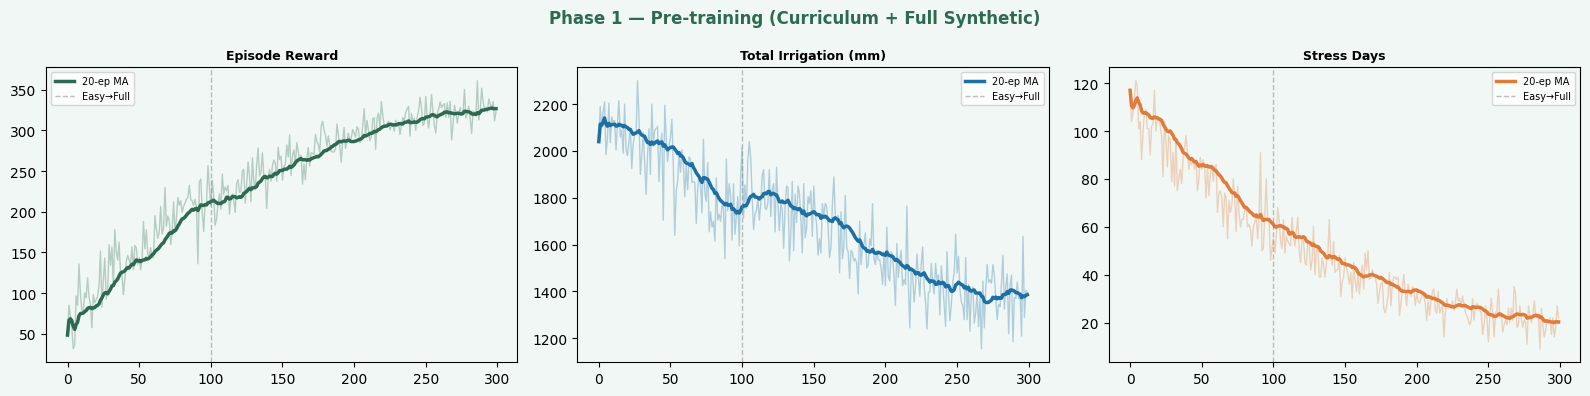

Phase 1: reward +82.1→+326.8  | stress 106→20 days


In [15]:
r1 = r1a + r1b; w1 = w1a + w1b; s1 = s1a + s1b

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#f0f7f4')
fig.suptitle('Phase 1 — Pre-training (Curriculum + Full Synthetic)',
             fontsize=12, fontweight='bold', color='#2d6a4f')
titles=['Episode Reward','Total Irrigation (mm)','Stress Days']
data=[r1,w1,s1]; colors=['#2d6a4f','#1d6fa4','#e07b39']
for ax,title,d,c in zip(axes,titles,data,colors):
    ax.plot(d,color=c,lw=1,alpha=0.3)
    ax.plot(pd.Series(d).rolling(20,min_periods=1).mean(),color=c,lw=2.5,label='20-ep MA')
    ax.axvline(100,color='gray',lw=1,ls='--',alpha=0.5,label='Easy→Full')
    ax.set_title(title,fontweight='bold',fontsize=9); ax.legend(fontsize=7)
    ax.set_facecolor('#f0f7f4')
plt.tight_layout()
plt.savefig('pretrain_curves.png',dpi=130,bbox_inches='tight')
plt.show()
print(f"Phase 1: reward {np.mean(r1[:20]):+.1f}→{np.mean(r1[-20:]):+.1f}  "
      f"| stress {np.mean(s1[:20]):.0f}→{np.mean(s1[-20:]):.0f} days")

## 13. Phase 2 — Fine-tune on Real Seasons

Replay buffer cleared → fine-tuning learns ONLY from real data.
ε starts at 0.35 → decays to ~0.06 over 200 episodes.

In [14]:
# Clear replay — critical for clean fine-tuning
agent.replay = ReplayBuffer(capacity=20000)
agent.eps    = 0.35
print(f"✅ Replay cleared | ε reset to {agent.eps}")

print()
print("=" * 72)
print("  PHASE 2 — Fine-tuning on 3 real seasons")
print("=" * 72)
env_real = IrrigationEnv(real_train)
r2,w2,s2,best_p2,br2,be2 = train(env_real, agent,
                                   n_episodes=200,
                                   phase_name="Fine-tune")
print(f"\n  Phase 2 done  |  Best reward: {br2:.1f} at ep {be2}")
print(f"  Final ε: {agent.eps:.3f}")

# Restore best checkpoint
agent.online.load_state_dict(best_p2)
print(f"\n✅ Best checkpoint restored (ep{be2}, reward={br2:.1f})")

✅ Replay cleared | ε reset to 0.35

  PHASE 2 — Fine-tuning on 3 real seasons
  [Fine-tune] Ep  20/200 | Reward=   283.3 | Avg20=  244.1 | Water= 1740mm | Stress= 37d | ε=0.304 | Best=283.3(ep20)
  [Fine-tune] Ep  40/200 | Reward=   212.2 | Avg20=  255.2 | Water= 1705mm | Stress= 38d | ε=0.264 | Best=292.4(ep38)
  [Fine-tune] Ep  60/200 | Reward=   302.1 | Avg20=  274.9 | Water= 1940mm | Stress= 25d | ε=0.230 | Best=318.3(ep45)
  [Fine-tune] Ep  80/200 | Reward=   312.7 | Avg20=  283.7 | Water= 1685mm | Stress= 25d | ε=0.200 | Best=320.0(ep74)
  [Fine-tune] Ep 100/200 | Reward=   254.8 | Avg20=  284.8 | Water= 1700mm | Stress= 22d | ε=0.173 | Best=320.0(ep74)
  [Fine-tune] Ep 120/200 | Reward=   337.5 | Avg20=  297.1 | Water= 1800mm | Stress= 12d | ε=0.151 | Best=337.5(ep120)
  [Fine-tune] Ep 140/200 | Reward=   318.2 | Avg20=  302.6 | Water= 1580mm | Stress= 25d | ε=0.131 | Best=339.2(ep128)
  [Fine-tune] Ep 160/200 | Reward=   281.9 | Avg20=  304.2 | Water= 1665mm | Stress= 13d | ε=0

## 14. Phase 2 Curves

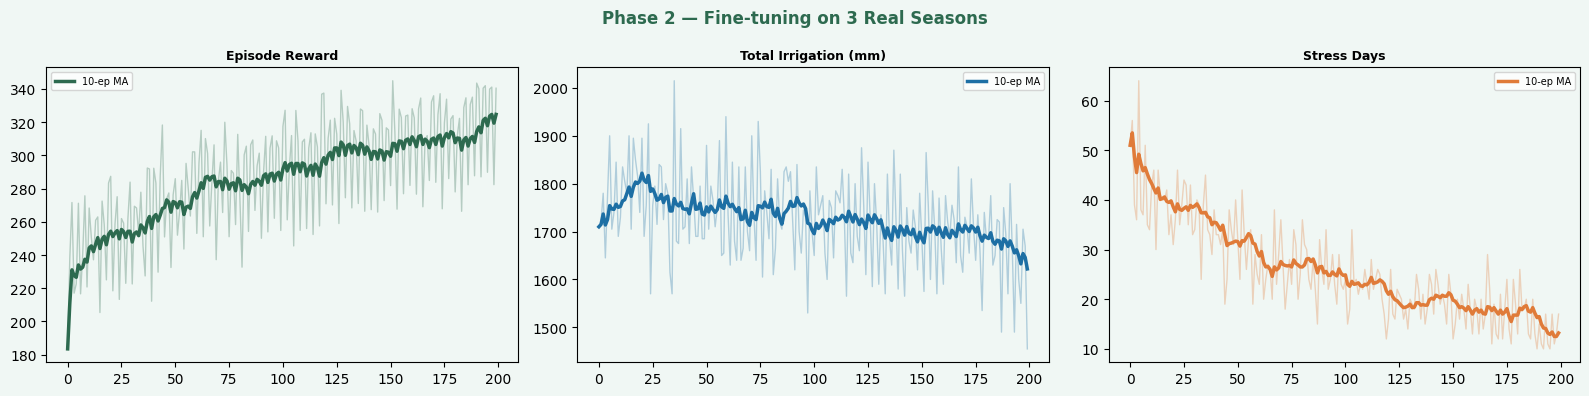

Phase 2: reward +235.8→+324.7  | stress 44→13 days


In [16]:
fig,axes=plt.subplots(1,3,figsize=(16,4),facecolor='#f0f7f4')
fig.suptitle('Phase 2 — Fine-tuning on 3 Real Seasons',
             fontsize=12,fontweight='bold',color='#2d6a4f')
for ax,title,d,c in zip(axes,titles,[r2,w2,s2],colors):
    ax.plot(d,color=c,lw=1,alpha=0.3)
    ax.plot(pd.Series(d).rolling(10,min_periods=1).mean(),color=c,lw=2.5,label='10-ep MA')
    ax.set_title(title,fontweight='bold',fontsize=9); ax.legend(fontsize=7)
    ax.set_facecolor('#f0f7f4')
plt.tight_layout()
plt.savefig('finetune_curves.png',dpi=130,bbox_inches='tight')
plt.show()
print(f"Phase 2: reward {np.mean(r2[:10]):+.1f}→{np.mean(r2[-10:]):+.1f}  "
      f"| stress {np.mean(s2[:10]):.0f}→{np.mean(s2[-10:]):.0f} days")

## 15. Real-only Baseline (400 episodes)

In [17]:
print("Training real-only baseline (400 eps) …")
agent_ro = DoubleDQNAgent(n_state=9, n_actions=N_ACTIONS,
                          lr=3e-4, gamma=0.95, eps_decay=0.993,
                          batch=128, min_replay=300)
r_ro,w_ro,s_ro,best_ro,br_ro,be_ro = train(
    IrrigationEnv(real_train), agent_ro,
    n_episodes=400, phase_name="Real-only")
agent_ro.online.load_state_dict(best_ro)
print(f"\n  Real-only done  |  Best reward: {br_ro:.1f} at ep {be_ro}")

Training real-only baseline (400 eps) …
  [Real-only] Ep  20/400 | Reward=    80.6 | Avg20=   67.1 | Water= 2120mm | Stress=113d | ε=0.869 | Best=106.6(ep15)
  [Real-only] Ep  40/400 | Reward=   126.8 | Avg20=  112.8 | Water= 1935mm | Stress= 70d | ε=0.755 | Best=151.6(ep39)
  [Real-only] Ep  60/400 | Reward=   174.3 | Avg20=  148.7 | Water= 1945mm | Stress= 73d | ε=0.656 | Best=195.0(ep48)
  [Real-only] Ep  80/400 | Reward=   146.4 | Avg20=  161.4 | Water= 1945mm | Stress= 85d | ε=0.570 | Best=202.9(ep78)
  [Real-only] Ep 100/400 | Reward=   192.2 | Avg20=  189.5 | Water= 1800mm | Stress= 43d | ε=0.495 | Best=243.6(ep99)
  [Real-only] Ep 120/400 | Reward=   247.0 | Avg20=  222.0 | Water= 1905mm | Stress= 46d | ε=0.430 | Best=267.0(ep119)
  [Real-only] Ep 140/400 | Reward=   254.9 | Avg20=  223.5 | Water= 1785mm | Stress= 47d | ε=0.374 | Best=267.0(ep119)
  [Real-only] Ep 160/400 | Reward=   235.2 | Avg20=  238.4 | Water= 1610mm | Stress= 29d | ε=0.325 | Best=279.2(ep158)
  [Real-only]

## 16. Evaluation on Test Season

In [18]:
# Evaluate all three policies on fresh env instances
rl_df = rollout(real_test, policy='rl',   agent=agent)
ro_df = rollout(real_test, policy='rl',   agent=agent_ro)
rb_df = rollout(real_test, policy='rule')

print(f"{'Metric':<32} {'Pretrain+FT':>13} {'Real-only':>11} {'Rule-Based':>11}")
print("-" * 70)
for name, v1, v2, v3 in [
    ("Total irrigation (mm)",   rl_df['irr_mm'].sum(),        ro_df['irr_mm'].sum(),        rb_df['irr_mm'].sum()),
    ("Optimal band days",        rl_df['in_opt'].sum(),        ro_df['in_opt'].sum(),         rb_df['in_opt'].sum()),
    ("Stress days",             (~rl_df['in_opt']).sum(),      (~ro_df['in_opt']).sum(),      (~rb_df['in_opt']).sum()),
    ("Total reward",             rl_df['reward'].sum(),        ro_df['reward'].sum(),         rb_df['reward'].sum()),
]:
    print(f"  {name:<30} {v1:>13.1f} {v2:>11.1f} {v3:>11.1f}")

Metric                             Pretrain+FT   Real-only  Rule-Based
----------------------------------------------------------------------
  Total irrigation (mm)                  780.0       735.0       100.0
  Optimal band days                       99.0       100.0        25.0
  Stress days                              6.0         5.0        80.0
  Total reward                           157.8       162.1       -30.3


## 17. Visualisation

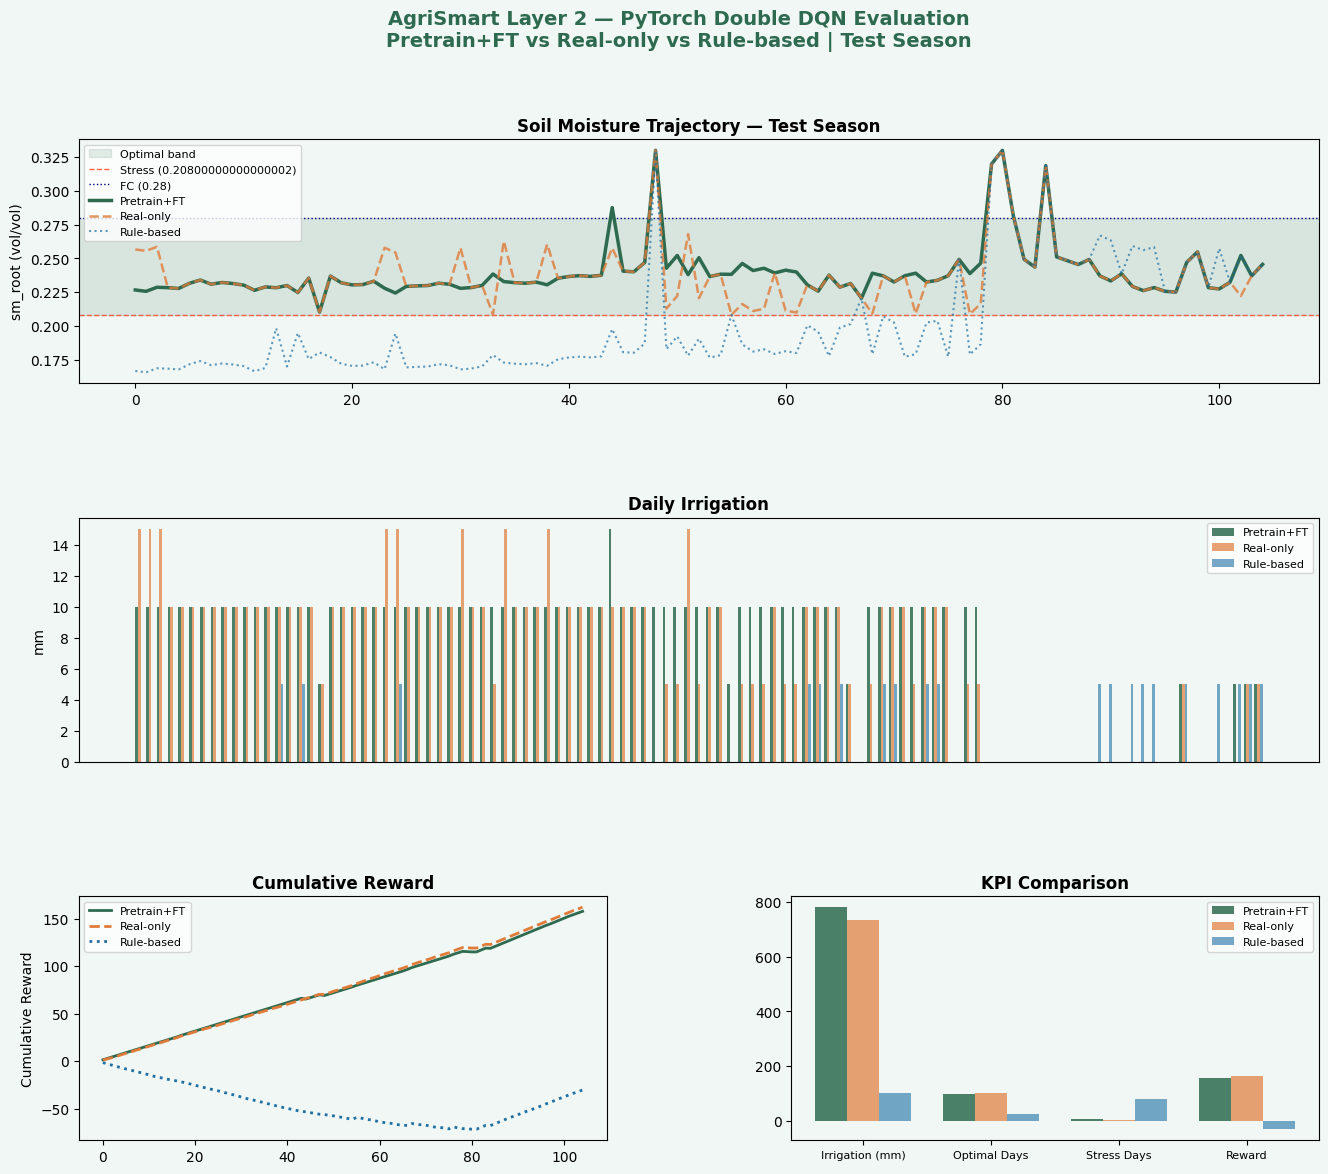

In [19]:
fig = plt.figure(figsize=(16, 13), facecolor='#f0f7f4')
fig.suptitle('AgriSmart Layer 2 — PyTorch Double DQN Evaluation\n'
             'Pretrain+FT vs Real-only vs Rule-based | Test Season',
             fontsize=14, fontweight='bold', color='#2d6a4f')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

ax1 = fig.add_subplot(gs[0,:])
ax1.axhspan(SM_LOW,SM_HIGH,alpha=0.12,color='#2d6a4f',label='Optimal band')
ax1.axhline(SM_LOW,color='tomato',lw=1,ls='--',label=f'Stress ({SM_LOW})')
ax1.axhline(FC,    color='navy',  lw=1,ls=':',label=f'FC ({FC})')
ax1.plot(range(len(rl_df)),rl_df['sm_root'],color='#2d6a4f',lw=2.5,label='Pretrain+FT')
ax1.plot(range(len(ro_df)),ro_df['sm_root'],color='#e07b39',lw=1.8,ls='--',alpha=0.8,label='Real-only')
ax1.plot(range(len(rb_df)),rb_df['sm_root'],color='#1d6fa4',lw=1.5,ls=':',alpha=0.7,label='Rule-based')
ax1.set_title('Soil Moisture Trajectory — Test Season',fontweight='bold')
ax1.set_ylabel('sm_root (vol/vol)'); ax1.legend(fontsize=8); ax1.set_facecolor('#f0f7f4')

ax2 = fig.add_subplot(gs[1,:])
x=np.arange(len(rl_df))
ax2.bar(x-0.25,rl_df['irr_mm'],0.25,color='#2d6a4f',alpha=0.85,label='Pretrain+FT')
ax2.bar(x,     ro_df['irr_mm'],0.25,color='#e07b39',alpha=0.70,label='Real-only')
ax2.bar(x+0.25,rb_df['irr_mm'],0.25,color='#1d6fa4',alpha=0.60,label='Rule-based')
ax2.set_title('Daily Irrigation',fontweight='bold'); ax2.set_ylabel('mm')
ax2.legend(fontsize=8); ax2.set_facecolor('#f0f7f4'); ax2.set_xticks([])

ax3 = fig.add_subplot(gs[2,0])
ax3.plot(rl_df['reward'].cumsum(),color='#2d6a4f',lw=2,label='Pretrain+FT')
ax3.plot(ro_df['reward'].cumsum(),color='#e07b39',lw=2,ls='--',label='Real-only')
ax3.plot(rb_df['reward'].cumsum(),color='#1d6fa4',lw=2,ls=':',label='Rule-based')
ax3.set_title('Cumulative Reward',fontweight='bold')
ax3.set_ylabel('Cumulative Reward'); ax3.legend(fontsize=8); ax3.set_facecolor('#f0f7f4')

ax4 = fig.add_subplot(gs[2,1])
kns=['Irrigation (mm)','Optimal Days','Stress Days','Reward']
vals=[[rl_df['irr_mm'].sum(),rl_df['in_opt'].sum(),(~rl_df['in_opt']).sum(),rl_df['reward'].sum()],
      [ro_df['irr_mm'].sum(),ro_df['in_opt'].sum(),(~ro_df['in_opt']).sum(),ro_df['reward'].sum()],
      [rb_df['irr_mm'].sum(),rb_df['in_opt'].sum(),(~rb_df['in_opt']).sum(),rb_df['reward'].sum()]]
x4=np.arange(4); w=0.25
ax4.bar(x4-w,vals[0],w,color='#2d6a4f',alpha=0.85,label='Pretrain+FT')
ax4.bar(x4,  vals[1],w,color='#e07b39',alpha=0.70,label='Real-only')
ax4.bar(x4+w,vals[2],w,color='#1d6fa4',alpha=0.60,label='Rule-based')
ax4.set_xticks(x4); ax4.set_xticklabels(kns,fontsize=8)
ax4.set_title('KPI Comparison',fontweight='bold')
ax4.legend(fontsize=8); ax4.set_facecolor('#f0f7f4')

plt.savefig('evaluation_results.png',dpi=140,bbox_inches='tight',facecolor='#f0f7f4')
plt.show()

## 18. Final KPI Summary

In [20]:
rl_r=rl_df['reward'].sum(); ro_r=ro_df['reward'].sum(); rb_r=rb_df['reward'].sum()
winner='Pretrain+FT' if rl_r>=ro_r else 'Real-only'
best_agent_final = agent if rl_r>=ro_r else agent_ro

print("="*72)
print("  AgriSmart Layer 2 (PyTorch Double DQN) — Final KPI Summary")
print("="*72)
print(f"  {'KPI':<32} {'Pretrain+FT':>13} {'Real-only':>11} {'Rule-Based':>11}")
print("-"*72)
for name,v1,v2,v3 in [
    ("Water used (mm)",        rl_df['irr_mm'].sum(),       ro_df['irr_mm'].sum(),       rb_df['irr_mm'].sum()),
    ("Optimal days (%)",       rl_df['in_opt'].mean()*100,  ro_df['in_opt'].mean()*100,  rb_df['in_opt'].mean()*100),
    ("Stress days",           (~rl_df['in_opt']).sum(),     (~ro_df['in_opt']).sum(),     (~rb_df['in_opt']).sum()),
    ("Total reward",           rl_r,                        ro_r,                         rb_r),
]:
    print(f"  {name:<32} {v1:>13.1f} {v2:>11.1f} {v3:>11.1f}")
print("="*72)
best_r=max(rl_r,ro_r)
print(f"\n  Winner           : {winner} (reward={best_r:.1f})")
print(f"  vs Rule-Based    : {best_r-rb_r:+.1f}")
print(f"  Pre-train bonus  : {rl_r-ro_r:+.1f}  ({'✓ helped' if rl_r>ro_r else '→ real-only wins'})")
print(f"  Stress reduction : {(~rl_df['in_opt']).sum()} vs {(~rb_df['in_opt']).sum()} days vs rule-based")

  AgriSmart Layer 2 (PyTorch Double DQN) — Final KPI Summary
  KPI                                Pretrain+FT   Real-only  Rule-Based
------------------------------------------------------------------------
  Water used (mm)                          780.0       735.0       100.0
  Optimal days (%)                          94.3        95.2        23.8
  Stress days                                6.0         5.0        80.0
  Total reward                             157.8       162.1       -30.3

  Winner           : Real-only (reward=162.1)
  vs Rule-Based    : +192.4
  Pre-train bonus  : -4.3  (→ real-only wins)
  Stress reduction : 6 vs 80 days vs rule-based


## 19. Save Best Agent

In [21]:
# Save best agent for LangGraph
best_agent_final.save('layer2_dqn_pytorch_best.pt')
print(f"✅ Saved: layer2_dqn_pytorch_best.pt  ({winner})")

# Also save in the format expected by LangGraph notebook
import torch
ck = torch.load('layer2_dqn_pytorch_best.pt', map_location='cpu')
torch.save(ck, 'layer2_dqn_agent_augmented.pt')
print(f"✅ Saved: layer2_dqn_agent_augmented.pt  (use this in LangGraph)")

print(f"Training complete! Winner: {winner} (reward={best_r:.1f})")
print(f"Architecture: PyTorch Double DQN  |  9->128->64->5")
print(f"Phase 1a: 100 eps easy synthetic")
print(f"Phase 1b: 200 eps all 1000 synthetic")
print(f"Phase 2 : 200 eps fine-tune on 3 real seasons")


✅ Saved: layer2_dqn_pytorch_best.pt  (Real-only)
✅ Saved: layer2_dqn_agent_augmented.pt  (use this in LangGraph)
Training complete! Winner: Real-only (reward=162.1)
Architecture: PyTorch Double DQN  |  9->128->64->5
Phase 1a: 100 eps easy synthetic
Phase 1b: 200 eps all 1000 synthetic
Phase 2 : 200 eps fine-tune on 3 real seasons
